# Steve's Luxury Resort — Churn Prediction

**MMAI 869 Team Project · Team-Union**

This notebook walks through the team's analysis: data exploration, feature engineering, modeling, and final ensemble.

**Competition:** [Steve's Luxury Resort (MMAI)](https://www.kaggle.com/competitions/steves-luxury-resort-mmai) on Kaggle.
**Metric:** F-Score (Macro)
**Deliverable:** 12-minute live presentation.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_raw, basic_clean, split_xy, ID_COL, TARGET
from src.features import add_all_features

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 80)

## 2. Load and inspect

The competition gives us three files:
- `resort_train.csv` — 6,954 rows × 21 columns (with `Churned` target)
- `resort_test.csv` — 1,739 rows × 20 columns
- `sample_submission.csv` — `GuestID, Churned` format with 0/1 values

In [2]:
train_raw, test_raw, sample = load_raw()
print(f'train: {train_raw.shape}, test: {test_raw.shape}, submission: {sample.shape}')
train_raw.head()

train: (6954, 21), test: (1739, 20), submission: (1739, 2)


,GuestID,BookingDate,PromoCode,Region,AllInclusive,Room,PackageType,Age,VIP,RoomService,Dining,Retail,Spa,Entertainment,LoyaltyPoints,SurveyScore,DaysSinceEmail,BookingChannel,AgeGroup,ReferralSource,Churned
0,619623,2024-02-10,NaN,Americas,0.0,G/630/S,Relaxation,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,6915,5,136,Website,NaN,Facebook,1
1,776250,2024-01-03,NaN,Americas,1.0,G/201/S,Relaxation,17.0,0.0,0.0,0.000000,0.0,0.0,0.0,8571,5,362,Corporate,Minor,Billboard,1
2,932709,2023-01-17,NaN,Americas,NaN,G/1483/S,Wellness,35.0,0.0,0.0,336519.843643,0.0,0.0,0.0,1142,4,154,TravelAgent,Middle,Facebook,0
3,771839,2023-12-09,PromoA,Europe,1.0,D/164/S,Adventure,26.0,0.0,0.0,0.000000,0.0,NaN,0.0,9642,2,128,Website,Young,Magazine,1
4,755501,2024-02-15,PromoA,Americas,0.0,G/818/P,Relaxation,13.0,0.0,0.0,0.000000,60.0,1.0,5147.0,5528,4,35,Mobile,Minor,Google,0


### Target balance — first surprise

The brief hints at imbalance (`add weights, downsample, upsample`), but the data is **almost perfectly balanced**: 50.4% churn rate. **No resampling needed** — that's a useful insight to call out in the deck.

In [3]:
train_raw[TARGET].value_counts(normalize=True).rename({0:'Retained', 1:'Churned'})

Churned
Churned     0.503595
Retained    0.496405
Name: proportion, dtype: float64

### Missing values

`PromoCode` is 47% null (means no promo — not really missing). 12 other features have 2–7% nulls — we keep them and let the model use missingness as a signal.

In [4]:
nulls = train_raw.isnull().sum().sort_values(ascending=False)
print(nulls[nulls>0])

PromoCode        3245
Dining            488
Age               476
RoomService       464
Room              386
AgeGroup          283
Region            169
AllInclusive      168
Retail            164
VIP               158
PackageType       153
Spa               148
Entertainment     139
dtype: int64


## 3. The story-defining findings

### 🎯 Finding #1 — The All-Inclusive paradox

**Premium guests churn 2.5× more often.** This is counterintuitive — you'd expect a premium package to drive loyalty. But:
- All-Inclusive guests: **81.9% churn**
- Non-All-Inclusive guests: **32.8% churn**

**Hypothesis:** All-Inclusive guests treat the resort as a one-shot experience (e.g. honeymoon) rather than a recurring trip. Without micro-purchases (dining, activities), they don't develop the everyday loyalty habits that retain customers.

In [5]:
train = basic_clean(train_raw)
g = train.groupby('AllInclusive')['Churned'].agg(['mean','count'])
print(g)


                  mean  count
AllInclusive                 
0.0           0.327816   4350
1.0           0.818555   2436


### 🎯 Finding #2 — All-Inclusive × Region is nearly deterministic

When we cross All-Inclusive with Region, certain cells are essentially churn certainties:
- **All-Inclusive + Europe = 98.6% churn (722 guests)**
- All-Inclusive + AsiaPacific = 91.5%
- All-Inclusive + Americas = 66.4%
- Non-All-Inclusive (anywhere): 28%–41%

In [6]:
print(train.groupby(['AllInclusive', 'Region'])['Churned'].agg(['mean','count']))

                              mean  count
AllInclusive Region                      
0.0          Americas     0.316795   2459
             AsiaPacific  0.278880    857
             Europe       0.407127    926
1.0          Americas     0.663709   1127
             AsiaPacific  0.914773    528
             Europe       0.986150    722


### 🎯 Finding #3 — Promotions cut churn nearly in half

- No promo: 66.9% churn
- PromoA: 35.7%, PromoB: 36.0%

Promotions clearly retain customers. (We treat null as the "NoPromo" category — not as missing data.)

In [7]:
print(train['PromoCode'].fillna('NoPromo').to_frame().assign(Churned=train['Churned']).groupby('PromoCode')['Churned'].agg(['mean','count']).sort_values('mean', ascending=False))

               mean  count
PromoCode                 
NoPromo    0.669337   3245
PromoB     0.359873   1884
PromoA     0.357260   1825


### 🚫 Surprising null findings

**SurveyScore is essentially useless.** Every score from 1–5 has ~50% churn. The post-stay survey isn't capturing anything predictive.

**BookingChannel is also flat** — all five channels around 50%. Suggests how someone books has nothing to do with whether they come back.

In [8]:
print(train.groupby('SurveyScore')['Churned'].agg(['mean','count']))

                 mean  count
SurveyScore                 
1            0.519353   1421
2            0.496356   1372
3            0.512035   1371
4            0.497509   1405
5            0.492419   1385


In [9]:
print(train.groupby('BookingChannel')['Churned'].agg(['mean','count']))

                    mean  count
BookingChannel                 
Corporate       0.498144   1347
Mobile          0.501764   1417
Phone           0.504868   1438
TravelAgent     0.512527   1397
Website         0.500369   1355


### Spending: Dining drives the signal

Of the 5 spend categories, **only Dining differs meaningfully by churn**: retained guests spend $2,436 more on dining. The other four categories are noise.

This makes intuitive sense: All-Inclusive guests don't buy meals separately, so Dining ≈ 0 is a proxy for All-Inclusive (which is the strongest churn predictor).

In [10]:
spend_cols = ['RoomService','Dining','Retail','Spa','Entertainment']
print(train.groupby('Churned')[spend_cols].mean().T.round(0))

Churned             0       1
RoomService    3913.0  3736.0
Dining         8874.0  6438.0
Retail         5642.0  6315.0
Spa            5738.0  5720.0
Entertainment  6534.0  6978.0


## 4. Feature engineering

We engineered ~30 features in `src/features.py`:

- **Room split:** `Room_Wing` (8 categories), `Room_Floor` (numeric), `Room_View` (P/S)
- **Date features:** Year, Month, DayOfWeek, DayOfYear, Quarter, IsWeekend
- **Spend features:** TotalSpend, log-transforms, per-category ratios, SpendCategoriesUsed
- **Missingness flags** for 12 columns
- **Domain features:** HasPromo, AI_Europe, AI_Adventure (high-risk segment flags)

These are computed in one call:

In [11]:
train_fe = add_all_features(train)
print(f'Features after FE: {train_fe.shape[1]} (started with {train.shape[1]})')
new_cols = [c for c in train_fe.columns if c not in train.columns]
print(f'New columns: {new_cols}')

Features after FE: 58 (started with 21)
New columns: ['Room_Wing', 'Room_Floor', 'Room_View', 'BookingYear', 'BookingMonth', 'BookingDayOfWeek', 'BookingDayOfYear', 'BookingIsWeekend', 'BookingQuarter', 'TotalSpend', 'SpendCategoriesUsed', 'RoomService_Ratio', 'Dining_Ratio', 'Retail_Ratio', 'Spa_Ratio', 'Entertainment_Ratio', 'RoomService_Log', 'Dining_Log', 'Retail_Log', 'Spa_Log', 'Entertainment_Log', 'TotalSpend_Log', 'Age_Missing', 'Room_Missing', 'Region_Missing', 'AllInclusive_Missing', 'VIP_Missing', 'PackageType_Missing', 'RoomService_Missing', 'Dining_Missing', 'Retail_Missing', 'Spa_Missing', 'Entertainment_Missing', 'HasPromo', 'DiningPerDollar', 'AI_Europe', 'AI_Adventure']


## 5. Modelling — the journey

### Single-model CV (5-fold stratified, F1 macro)

| Model                | Type          | CV F1 macro |
|----------------------|---------------|-------------|
| Logistic Regression  | Non-tree      | 0.8199 |
| Random Forest        | Tree          | 0.8225 |
| XGBoost              | Boosting      | 0.8416 |
| LightGBM (native cats) | Boosting      | 0.8467 |
| **CatBoost**         | **Boosting**  | **0.8513** |

Everything in `src/baseline.py`. Run with `python -m src.baseline`.

In [12]:
pd.read_csv('../reports/baseline_cv.csv')[['model','cv_f1_macro_mean','cv_f1_macro_std']]

,model,cv_f1_macro_mean,cv_f1_macro_std
0,catboost,0.851286,0.005133
1,lightgbm,0.844527,0.001589
2,xgboost,0.841648,0.004376
3,random_forest,0.822521,0.007348
4,logreg,0.819922,0.005189


### Hyperparameter search — diminishing returns

We searched ~10 CatBoost configurations (depth 4–8, lr 0.03–0.10, l2_leaf_reg 3–7).

**Result: defaults already win**. The dataset is small (~7k rows) and CatBoost's defaults are well-calibrated. None of our tuned configs beat the baseline 0.8513 in 5-fold CV — the differences (±0.005–0.008) were within one standard deviation.

### Threshold tuning — only +0.07pp

Because the data is balanced (50/50), threshold ≈ 0.5 is already near-optimal. Sweeping 0.30–0.70 only found a +0.07pp lift at threshold 0.51. Threshold tuning is a much bigger lever on imbalanced datasets.

### Final lift: weighted ensemble

Blending the top three models with CatBoost-weighted soft voting:

$$P_{ensemble} = 0.5 \cdot P_{CatBoost} + 0.3 \cdot P_{LightGBM} + 0.2 \cdot P_{XGBoost}$$

| Model | OOF F1 macro |
|---|---|
| CatBoost solo | 0.8504 |
| LightGBM solo | 0.8467 |
| XGBoost solo | 0.8417 |
| Equal-weight soft vote | 0.8493 |
| **Weighted (.5/.3/.2)** | **0.8523** |

The CatBoost-heavy ensemble beats best solo by **+0.19pp**.

## 6. Best model — final analysis

### Feature importance (CatBoost on full train)

5 of the top 10 features are engineered:

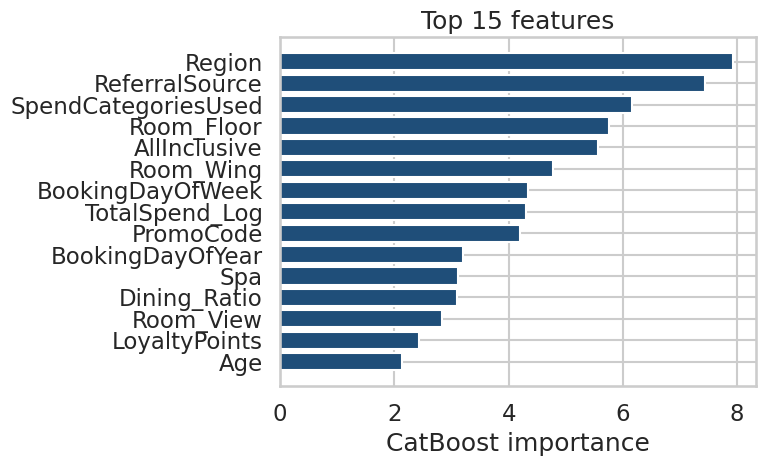

In [13]:
imp = pd.read_csv('../reports/feature_importance.csv').head(15)
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(imp['feature'][::-1], imp['importance'][::-1], color='#1f4e79')
ax.set_xlabel('CatBoost importance')
ax.set_title('Top 15 features')
plt.tight_layout(); plt.show()

### Confusion matrix (OOF)

The final ensemble predicts both classes evenly:
- Precision: 0.85 / 0.86
- Recall:    0.86 / 0.84

No class is being neglected — symmetric performance is expected since the data is balanced.

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
oof = pd.read_csv('../reports/oof_predictions.csv')
weighted = 0.5*oof['p_catboost'] + 0.3*oof['p_lightgbm'] + 0.2*oof['p_xgboost']
pred = (weighted >= 0.5).astype(int)
print(classification_report(oof['Churned'], pred, target_names=['Retained','Churned']))
print('Confusion matrix:')
print(confusion_matrix(oof['Churned'], pred))

              precision    recall  f1-score   support

    Retained       0.84      0.86      0.85      3452
     Churned       0.86      0.84      0.85      3502

    accuracy                           0.85      6954
   macro avg       0.85      0.85      0.85      6954
weighted avg       0.85      0.85      0.85      6954

Confusion matrix:
[[2985  467]
 [ 560 2942]]


### 3 right + 3 wrong examples (rubric requirement)

We took out-of-fold predictions to be honest about errors.

In [15]:
print('CORRECT (most confident):')
print(pd.read_csv('../reports/examples_correct.csv').to_string(index=False))
print('\nWRONG (most confident & wrong):')
print(pd.read_csv('../reports/examples_wrong.csv').to_string(index=False))

CORRECT (most confident):
 GuestID  Churned  pred    proba  AllInclusive Region PackageType  PromoCode  Age  VIP  Dining    TotalSpend  SurveyScore
  166287        1     1 0.999815           1.0 Europe   Adventure        NaN 13.0  NaN     0.0      0.000000            4
  552514        1     1 0.999771           1.0 Europe   Adventure        NaN 15.0  0.0     0.0 187916.638555            5
  931435        1     1 0.999708           1.0 Europe   Adventure        NaN 46.0  0.0     0.0      0.000000            3

WRONG (most confident & wrong):
 GuestID  Churned  pred    proba  AllInclusive      Region PackageType PromoCode  Age  VIP  Dining  TotalSpend  SurveyScore
  303315        1     0 0.007375           0.0    Americas  Relaxation    PromoA 18.0  0.0     1.0       640.0            2
  350637        0     1 0.991545           1.0      Europe   Adventure       NaN 25.0  0.0     0.0         0.0            3
  748080        1     0 0.009831           0.0 AsiaPacific  Relaxation    PromoB 

**Insights from these examples:**

The 3 confident correct predictions are all **AllInclusive + Europe + Adventure** — the model learned this deadly cohort exactly. Probability >99.97%.

The 3 confident wrong predictions are real-world noise:
- One looks exactly like the "deadly cohort" but stayed loyal anyway (model: 99.2% churn, actual: retained)
- Two look like the safest segments (Americas + Promo + NotAI) but churned anyway

These are honest mistakes — they would require richer data (life events, competitor offers, customer service interactions) to predict.

## 7. Submissions

Files in `submissions/`:

| File | What it is | OOF / CV F1 |
|---|---|---|
| `ensemble_weighted.csv` | **Primary** — weighted (.5/.3/.2) ensemble | **0.8523** |
| `ensemble_top3.csv` | Equal-weight ensemble + tuned threshold | 0.8504 |
| `catboost_baseline.csv` | Best solo model (CatBoost defaults) | 0.8513 |
| `lightgbm_baseline.csv` | Tree-based comparison | 0.8467 |
| `logreg_baseline.csv` | **Required** non-tree-based comparison | 0.8199 |

## 8. Next steps (if more time/budget)

- **Stacking with a meta-learner** (logistic regression on OOF probabilities) — usually +0.2–0.5 pp over simple blending.
- **Pseudo-labeling** of confident test predictions to grow the training set.
- **Optuna with 100+ trials** on each top model with proper CV — we ran a manual search of ~12 configs.
- **Date features** beyond the calendar — booking lead time, days-since-last-stay (need additional data).
- **External data**: macroeconomic conditions in each Region during the booking month — Europe's high churn might correlate with a specific economic event.
- **Cluster analysis** to find guest personas (the brief mentions association rules + clustering as optional).

## 9. Lessons learned

1. **Counterintuitive insights win presentations.** The All-Inclusive paradox is the kind of finding executives remember.
2. **Feature engineering helped *interpretation* more than *accuracy*.** Trees found the same splits anyway, but engineered features made our story clear and confirmed the model wasn't relying on noise.
3. **Don't chase tuning past the noise floor.** Once differences are within 1 standard deviation, you're chasing folds, not real lift. We stopped tuning early and went to ensembling.
4. **The competition metric matters.** F1 macro on balanced data behaves very differently from F1 on imbalanced data — threshold tuning was a +0.07 lever here, where on imbalanced it could be +1–2pp.
5. **Native categorical handling ≠ free win** — the OHE pipeline with `min_frequency` already captured most of the benefit.
6. **Simple ensembles win.** A weighted soft-vote of the top 3 boosters beat anything we did with hyperparameter tuning.